 Suno AI Reddit Dataset Exploratory Analysis

 This notebook explores the merged JSONL dataset:

 - Counts total posts and downloaded songs

 - Counts posts with predicted genres

 - Visualizes the most common genres

 - Analyzes top-3 genres distribution

 - Explores genre score distributions

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Configure pandas display
pd.set_option("display.max_columns", None)


 ## 1. Load Data

 Read the JSONL file into a DataFrame.

In [10]:
data_path = "suno_ai_dataset_with_lyrics_20250515_204541.csv"
df = pd.read_csv(data_path)
df.head()


,id,author,url,title,download_path,flair,suno_url,post_text,predicted_genres,top_3_genres,genre_scores,over_18,retrieved_on,num_comments,ups,downs,reddit_url,lyrics,suno_tags,instrumental
0,1c6q7op,GewoonRobinn13,https://suno.com/song/b99e8ada-0a7f-496b-ab32-...,Made a song about being a plant parent. I hope...,dataset/suno/1c6q7op.mp3,Song,https://suno.com/song/b99e8ada-0a7f-496b-ab32-...,NaN,[],"['jazz', 'country', 'folk']","[0.2537326515, 0.1759615242, 0.16200187800000002]",False,1713401009,0,1,0,https://www.reddit.com/r/SunoAI/comments/1c6q7...,"[intro]\n\n[verse 1]\nToday I bought plant,\nT...","[""Harmonica"", ""Fiddle"", ""60's"", ""blues"", ""folk...",False
1,1c6qcaa,GewoonRobinn13,https://suno.com/song/b99e8ada-0a7f-496b-ab32-...,I made a song about being a plant parent. I ho...,dataset/suno/1c6qcaa.mp3,Song,https://suno.com/song/b99e8ada-0a7f-496b-ab32-...,NaN,[],"['jazz', 'country', 'folk']","[0.2537326515, 0.1759615242, 0.16200187800000002]",False,1713401377,0,0,0,https://www.reddit.com/r/SunoAI/comments/1c6qc...,"[intro]\n\n[verse 1]\nToday I bought plant,\nT...","[""Harmonica"", ""Fiddle"", ""60's"", ""blues"", ""folk...",False
2,1c6qesm,Cardboard_Chef,https://suno.com/song/c7fd4cbd-c432-4ab5-831b-...,I think Suno does and incredible job at making...,dataset/suno/1c6qesm.mp3,Song,https://suno.com/song/c7fd4cbd-c432-4ab5-831b-...,NaN,[],"['electronic', 'pop', 'rock']","[0.3871032596, 0.2404211164, 0.2153102458]",False,1713401576,4,5,0,https://www.reddit.com/r/SunoAI/comments/1c6qe...,"(Verse 1)\nOnce a beacon in the night,\nNow co...","[""synthwave with saxophone""]",False
3,1c6qfbw,RDCK78,https://www.reddit.com/r/SunoAI/comments/1c6qf...,"First try at a country song, first try at any ...",dataset/suno/1c6qfbw.mp3,Song,https://suno.com/song/16c93478-bb0f-4ea4-99ba-...,https://suno.com/song/16c93478-bb0f-4ea4-99ba-...,['pop'],"['pop', 'rock', 'poprock']","[0.6949518919000001, 0.4699110687, 0.1709648073]",False,1713401617,6,2,0,https://www.reddit.com/r/SunoAI/comments/1c6qf...,"Pullin' 40 tons of trouble, Do'in 55 an hour \...","[""Country truck driving music""]",False
4,1c6qhdw,FluffyBrewbs,https://suno.com/song/2326aac2-42b4-4cb7-a428-...,Didn't think AI would make me cry,dataset/suno/1c6qhdw.mp3,Song,https://suno.com/song/2326aac2-42b4-4cb7-a428-...,I wrote lyrics to a song a couple years ago an...,['classical'],"['classical', 'soundtrack', 'easylistening']","[0.8194063902000001, 0.38395628330000003, 0.24...",False,1713401782,4,0,0,https://www.reddit.com/r/SunoAI/comments/1c6qh...,"(Verse 1)\nStaring out at the endless sea,\nA ...","[""Sad ambient piano with cinematic orchestra""]",False


 ## 2. Basic Counts

 - Total posts

 - How many have a downloaded audio file (`download_path`)\#

 - How many have predicted genres

In [11]:
import ast

# Fix predicted_genres column - convert string representations to actual lists
def safe_eval_list(x):
    """Safely convert string representation of list to actual list"""
    if pd.isna(x) or x == '' or x == 'nan':
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            # Try to evaluate as Python literal
            result = ast.literal_eval(x)
            return result if isinstance(result, list) else []
        except (ValueError, SyntaxError):
            # If that fails, try to parse as comma-separated values
            cleaned = x.strip('[]').replace("'", "").replace('"', '')
            if cleaned:
                return [item.strip() for item in cleaned.split(',')]
            return []
    return []

# Apply the fix
df['predicted_genres'] = df['predicted_genres'].apply(safe_eval_list)
df['top_3_genres'] = df['top_3_genres'].apply(safe_eval_list)

# Also fix genre_scores if it exists and has similar issues
if 'genre_scores' in df.columns:
    def safe_eval_scores(x):
        if pd.isna(x) or x == '' or x == 'nan':
            return []
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            try:
                result = ast.literal_eval(x)
                return result if isinstance(result, list) else []
            except (ValueError, SyntaxError):
                return []
        return []
    
    df['genre_scores'] = df['genre_scores'].apply(safe_eval_scores)

# Verify the fix worked
print("Sample predicted_genres after fix:")
print(df['predicted_genres'].head())
print(f"\nType of first non-null predicted_genres: {type(df['predicted_genres'].dropna().iloc[0])}")

Sample predicted_genres after fix:
0             []
1             []
2             []
3          [pop]
4    [classical]
Name: predicted_genres, dtype: object

Type of first non-null predicted_genres: <class 'list'>


In [12]:
# Total posts
total_posts = len(df)
# Downloaded songs
downloaded = df["download_path"].notnull().sum()
# Have at least one predicted genre
has_genre = (
    df["predicted_genres"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
)

print(f"Total posts: {total_posts}")
print(f"Downloaded songs: {downloaded}")
print(f"Posts with predicted genres: {has_genre}")


Total posts: 4059
Downloaded songs: 4059
Posts with predicted genres: 1782


 ## 3. Most Common Predicted Genres

 Flatten all predicted genres and count occurrences.

In [13]:
all_genres_series = df.loc[
    df["predicted_genres"].map(bool), "predicted_genres"
].explode()
genre_counts = all_genres_series.value_counts()
print(genre_counts.head(10))


predicted_genres
rock          435
pop           407
electronic    392
classical     185
metal         119
hiphop        102
soundtrack     60
reggae         35
rap            33
ambient        23
Name: count, dtype: int64


 ## 4. Plot Top Predicted Genres

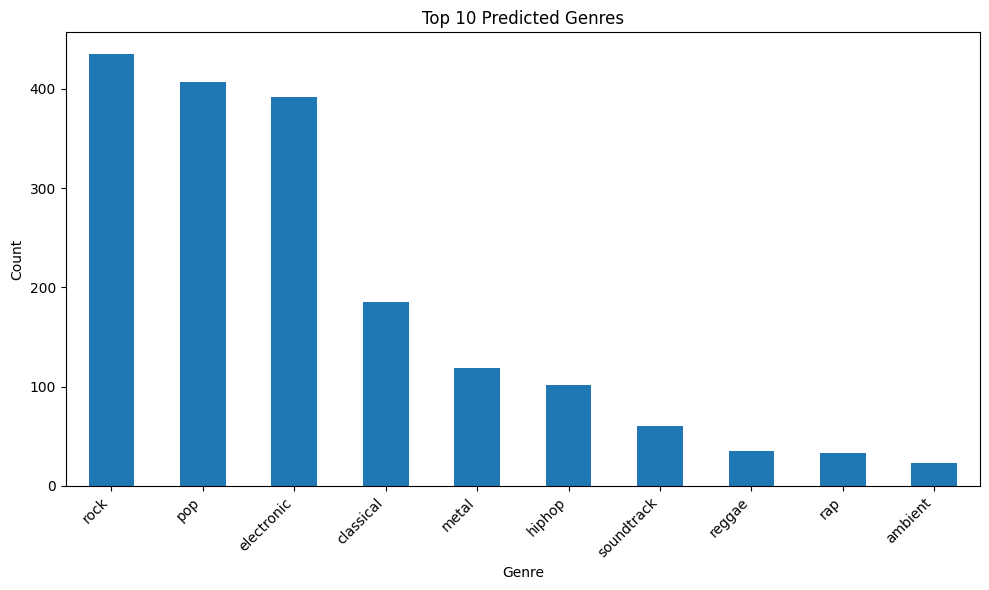

In [14]:
plt.figure(figsize=(10, 6))
genre_counts.head(10).plot(kind="bar")
plt.title("Top 10 Predicted Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 5. Distribution of Number of Predicted Genres per Post

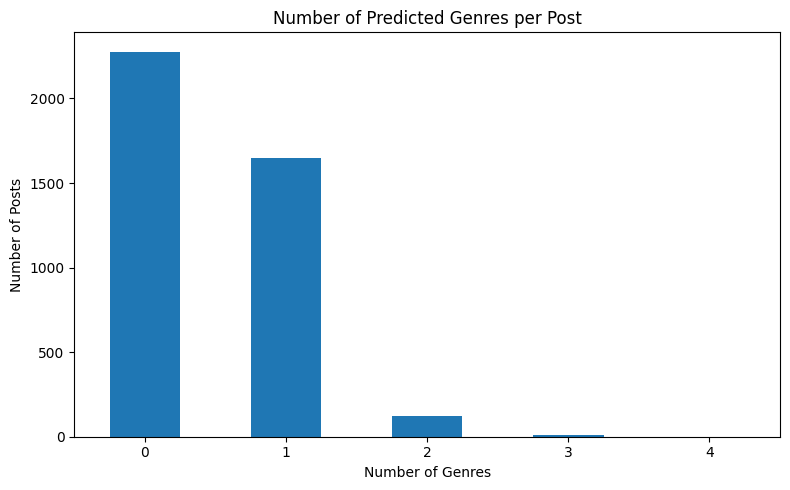

In [15]:
df["num_predicted"] = df["predicted_genres"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
counts_per_song = df["num_predicted"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
counts_per_song.plot(kind="bar")
plt.title("Number of Predicted Genres per Post")
plt.xlabel("Number of Genres")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


 ## 6. Most Common Top-3 Genres

 Flatten the `top_3_genres` lists and count.

In [16]:
top3_series = df.loc[df["top_3_genres"].map(bool), "top_3_genres"].explode()
top3_counts = top3_series.value_counts()
print(top3_counts.head(10))


top_3_genres
pop            2060
electronic     1830
rock           1412
soundtrack      841
ambient         602
classical       562
alternative     526
hiphop          479
popfolk         400
metal           376
Name: count, dtype: int64


 ## 7. Plot Top-3 Genre Counts

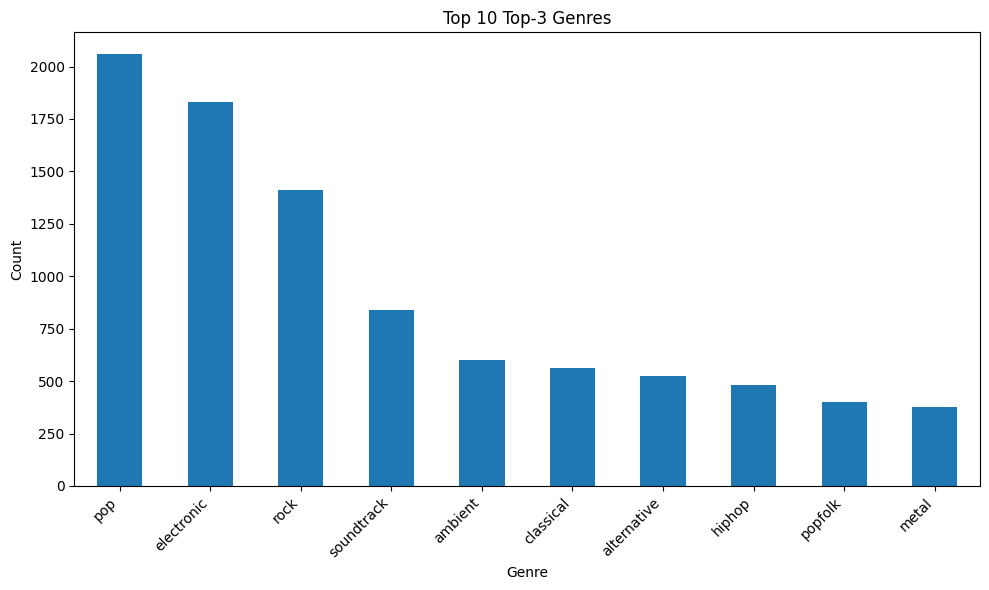

In [17]:
plt.figure(figsize=(10, 6))
top3_counts.head(10).plot(kind="bar", color=None)
plt.title("Top 10 Top-3 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Posts with user-specified genres in title: 3478

Top 15 user-specified genres:
user_genres
pop                170
rock               127
country            109
metal               83
rap                 82
r&b                 48
hip-hop             41
gregorian chant     36
edm                 36
funk                32
blues               30
hip hop             30
electronic          28
folk                23
indie rock          22
Name: count, dtype: int64


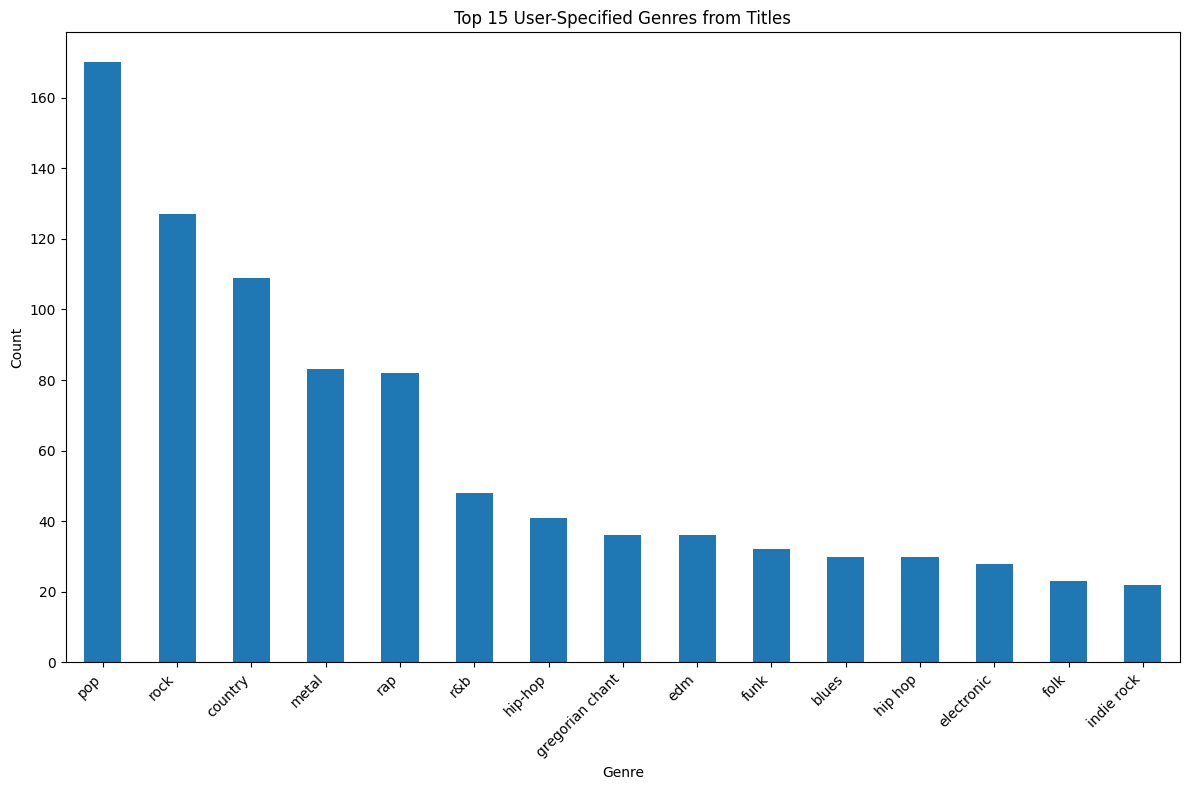


Sample titles with extracted genres:
Title: [Orchestral] "Михаил Шуфутинский - 3-е сентября | Epic Version", Wagon_Sala ("Sy...
Extracted genres: ['orchestral']

Title: [Orchestral] "Михаил Шуфутинский - 3-е сентября | Epic Version" by Wagon_Sala ("...
Extracted genres: ['orchestral']

Title: [rap] Hot There, by yamfboy...
Extracted genres: ['rap']

Title: [jazz] Atom Bomb Delight by Tingletip: Used chat-gpt to get the lyrics I wanted ...
Extracted genres: ['jazz']

Title: [Modern Country] Land of the Free by Morgon Branning...
Extracted genres: ['modern country']



In [ ]:
import re

# Extract user-specified genres from titles
def extract_user_genres(title):
    """Extract genres from title in format [genre1, genre2, ...]"""
    if pd.isna(title):
        return []
    
    # Look for patterns like [genre], [genre1, genre2], etc.
    pattern = r'\[([^\]]+)\]'
    matches = re.findall(pattern, title)
    
    if not matches:
        return []
    
    # Take the first bracket (assuming it contains genres)
    genre_text = matches[0]
    
    # Split by comma and clean up
    genres = [genre.strip().lower() for genre in genre_text.split(',') if genre.strip()]
    
    return genres

# Apply extraction
df['user_genres'] = df['title'].apply(extract_user_genres)

# Count posts with user-specified genres
has_user_genres = df['user_genres'].apply(lambda x: len(x) > 0).sum()
print(f"Posts with user-specified genres in title: {has_user_genres}")

# Flatten and count user genres
user_genres_series = df.loc[df['user_genres'].map(bool), 'user_genres'].explode()
user_genre_counts = user_genres_series.value_counts()

print(f"\nTop 10 user-specified genres:")
print(user_genre_counts.head(10))

# Plot user-specified genres
plt.figure(figsize=(12, 8))
user_genre_counts.head(10).plot(kind='bar')
plt.title('Top 10 User-Specified Genres from Titles')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show some examples
print(f"\nSample titles with extracted genres:")
sample_with_genres = df[df['user_genres'].map(bool)][['title', 'user_genres']].head(5)
for _, row in sample_with_genres.iterrows():
    print(f"Title: {row['title'][:80]}...")
    print(f"Extracted genres: {row['user_genres']}\n")

 ## 8. Genre Score Analysis

 Build a long-form DataFrame of each top-3 genre with its score and position.

In [18]:
records = []
for _, row in df.iterrows():
    genres = row.get("top_3_genres") or []
    scores = row.get("genre_scores") or []
    for pos, (g, s) in enumerate(zip(genres, scores), start=1):
        records.append({"position": pos, "genre": g, "score": s})
scores_long = pd.DataFrame(records)

# Descriptive stats
desc = scores_long["score"].describe()
print(desc)


count    37725.000000
mean         0.314817
std          0.163505
min          0.021434
25%          0.188548
50%          0.271266
75%          0.409008
max          0.997083
Name: score, dtype: float64


 ### 8.1 Score Distribution by Position

<Figure size 800x600 with 0 Axes>

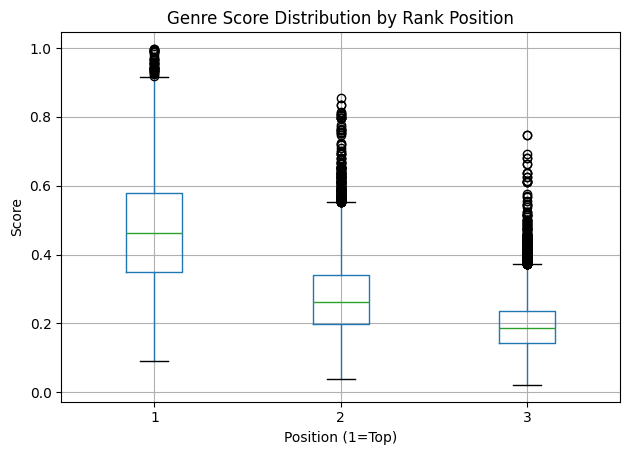

In [19]:
plt.figure(figsize=(8, 6))
scores_long.boxplot(column="score", by="position")
plt.title("Genre Score Distribution by Rank Position")
plt.suptitle("")  # remove automatic title
plt.xlabel("Position (1=Top)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


 ### 8.2 Average Score of Top-1 Genres

In [8]:
avg_top1 = (
    scores_long[scores_long["position"] == 1]
    .groupby("genre")["score"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_top1.head(10))

plt.figure(figsize=(10, 6))
avg_top1.head(10).plot(kind="bar")
plt.title("Average Score for Top-1 Genres")
plt.xlabel("Genre")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


NameError: name 'scores_long' is not defined

 ## 9. Save Summaries

 - Genre counts and top-3 counts to CSV

 - Scores long-form to CSV

In [ ]:
# summary = pd.DataFrame({"genre": genre_counts.index, "count": genre_counts.values})
# summary.to_csv("predicted_genre_counts.csv", index=False)

# top3_summary = pd.DataFrame({"genre": top3_counts.index, "count": top3_counts.values})
# top3_summary.to_csv("top3_genre_counts.csv", index=False)

# scores_long.to_csv("genre_scores_long.csv", index=False)
# print("Saved summaries to CSV files.")


Saved summaries to CSV files.
